### **Saniya Sayyed | 221A014 | 37**

---



### **Implementing a simple grid world env and training an agent using basic q-learning.**

## **Import dependencies**

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
import gymnasium
import numpy as np

Arman Sayyed | 221A008 | 36


### **Load Environment**

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
env = gymnasium.make("Taxi-v3",render_mode="rgb_array")

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
state = env.reset()

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
state

Arman Sayyed | 221A008 | 36


(281, {'prob': 1.0, 'action_mask': array([1, 1, 0, 1, 0, 0], dtype=int8)})

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
env.observation_space.n

Arman Sayyed | 221A008 | 36


np.int64(500)

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
env.action_space.n

Arman Sayyed | 221A008 | 36


np.int64(6)

Arman Sayyed | 221A008 | 36


array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
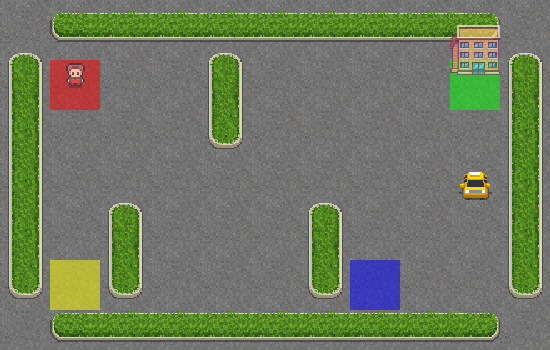

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
env.render()

### **Possible actions**

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
n_actions = env.action_space.n
n_states = env.observation_space.n

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
n_actions

Arman Sayyed | 221A008 | 36


np.int64(6)

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
n_states

Arman Sayyed | 221A008 | 36


np.int64(500)

### **How good does behaving randomly do?**

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
state = env.reset()
counter = 0
g = 0
reward = None

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
while reward != 20:
  state, reward, terminated, truncated, info = env.step(env.action_space.sample())
  done = terminated or truncated # 'done' is true if either terminated or truncated
  counter += 1
  g += reward

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
print("Solved in {} steps with a total reward of {}".format(counter,g))

Arman Sayyed | 221A008 | 36
Solved in 545 steps with a total reward of -2108


### **Episode 1 of training agent using Q-learning**

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
Q=np.zeros([n_states,n_actions])

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
n_actions

Arman Sayyed | 221A008 | 36


np.int64(6)

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
episodes = 1
G=0
alpha=0.618

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
for episodes in range(1,episodes+1):
  done=False
  G,reward=0,0
  # env.reset() returns (observation, info) in Gymnasium
  observation, info = env.reset()
  state = observation # Use the integer observation for Q-table indexing
  finalState = observation # Ensure finalState also stores the integer observation if used later
  print("Initial state {}".format(state))
  while reward != 20:
    action=np.argmax(Q[state])
    # env.step() returns (observation, reward, terminated, truncated, info) in Gymnasium
    next_observation, reward, terminated, truncated, info = env.step(action)
    state2 = next_observation # Use the integer observation for next state

    # Update 'done' based on Gymnasium's new return values
    done = terminated or truncated # 'done' is true if either terminated or truncated

    Q[state,action] = Q[state,action] + alpha * (reward + np.max(Q[state2]) - Q[state,action])
    G += reward
    state = state2 # Update state for next iteration

Arman Sayyed | 221A008 | 36
Initial state 167


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
finalState=state

Arman Sayyed | 221A008 | 36


In [ ]:
print("Saniya Sayyed | 221A014 | 37")
finalState

Arman Sayyed | 221A008 | 36


475

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
G

Arman Sayyed | 221A008 | 36


-663

### **For Multiple episodes**

In [ ]:
print("Saniya Sayyed | 221A014 | 37")
episodes = 2000
rewardTracker = []

for episode in range(1,episodes+1):
  done = False
  G, reward = 0,0
  # env.reset() returns (observation, info) in Gymnasium
  observation, info = env.reset()
  state = observation # Use the integer observation for Q-table indexing

  while done!= True:
    action = np.argmax(Q[state])
    # env.step() returns (observation, reward, terminated, truncated, info) in Gymnasium
    next_observation, reward, terminated, truncated, info = env.step(action)
    state2 = next_observation # Use the integer observation for next state

    # Update 'done' based on Gymnasium's new return values
    done = terminated or truncated # 'done' is true if either terminated or truncated

    rewardTracker.append(reward)
    Q[state,action] += alpha * (reward + np.max(Q[state2]) - Q[state,action])
    G += reward
    state = state2

  if episode % 100 == 0:
    print('Episode {} Total Reward: {}'.format(episode,G))

Arman Sayyed | 221A008 | 36
Episode 100 Total Reward: -68
Episode 200 Total Reward: 7
Episode 300 Total Reward: 8
Episode 400 Total Reward: 5
Episode 500 Total Reward: 7
Episode 600 Total Reward: 5
Episode 700 Total Reward: 6
Episode 800 Total Reward: 12
Episode 900 Total Reward: 6
Episode 1000 Total Reward: 12
Episode 1100 Total Reward: 5
Episode 1200 Total Reward: 6
Episode 1300 Total Reward: 9
Episode 1400 Total Reward: 6
Episode 1500 Total Reward: 10
Episode 1600 Total Reward: 9
Episode 1700 Total Reward: 6
Episode 1800 Total Reward: 4
Episode 1900 Total Reward: 9
Episode 2000 Total Reward: 9
